In [1]:
%load_ext autoreload
%autoreload 2

import warnings 
from pathlib import Path

import jax
import numpy as np
jax.config.update("jax_enable_x64", True)

import seaborn as sns

import sklearn.gaussian_process.kernels as gp_kern
from sklearn.gaussian_process import GaussianProcessRegressor

from source.features import PPFeature
from source.models.LaplaceCPR import LaplaceCPR
from source.models.MeanFieldBTN import MeanFieldBTN
from source.models.StructPostBTN import StructPostBTN
from source.general_functions import create_dir_if_not_exists
from source.visuals import plot_x3_results_multiple

sns.set_theme()
warnings.filterwarnings("ignore")

### Generate Data:

In [2]:
def generate_x3_data(n_samples, d_dim, min_v=-4, max_v=4, std_err=3, seed=None, sort_x=True):
    rs = np.random.RandomState(seed)
    x = rs.uniform(min_v, max_v, (n_samples, d_dim))
    if sort_x:
        x = np.sort(x, axis=0)
    e = rs.normal(0.0, std_err, (n_samples,))
    y_true = (x**3).sum(axis=1)
    y = y_true + e
    return x, y, y_true

n_samples, n_samples_test, d_dim, std_err, seed = 20, 100, 1, 3, 13
x_train, y_train, _ = generate_x3_data(n_samples, d_dim, std_err=std_err, seed=seed)
x_test, y_test, y_test_true = generate_x3_data(
    n_samples_test, d_dim, min_v=-5, max_v=5, std_err=std_err, seed=seed+10
)

### Generate Results:

In [3]:
def train_and_evaluate_models(models: dict[str, object], data):
    x_train, x_test, y_train, _ = data
    results = {}
    for model_name, model in models.items():
        print(f"Training model: {model_name}")
        model.fit(x_train, y_train)
        pred_mean, pred_std = model.predict(x_test, return_std=True)
        results[model_name] = {"pred_mean": pred_mean, "pred_std": pred_std}
    return results

# Shared hyperparameters
beta_e, gamma_w = 1/std_err**2, None
rank, fmap, m_order, n_epoch, n_loss_samples = 2, PPFeature(), 4, 1000, 1

models = {
    "MF-BTN": MeanFieldBTN(
        rank, fmap, m_order, n_epoch, beta_e, gamma_w, seed=seed, 
        opt_params={'train_mode': 'GD', 'lr': 1e-6}, n_loss_samples=n_loss_samples,
    ),
    "SP-BTN": StructPostBTN(
        rank, fmap, m_order, n_epoch, beta_e, gamma_w, seed=seed, 
        opt_params={'train_mode': 'GD', 'lr': 1e-6}, n_loss_samples=n_loss_samples, m_rank=2,
    ),
    "GP": GaussianProcessRegressor(
        kernel=gp_kern.DotProduct()**3 + gp_kern.WhiteKernel(1), 
        random_state=0
    ),
    "LA-BTN": LaplaceCPR(
        rank, fmap, m_order, n_epoch, beta_e, gamma_w, seed=seed,
        pd_mode='lla', hess_type='last', pd_sample_seed=seed,
    ),
}

data = (x_train, x_test, y_train, y_test)
model2res = train_and_evaluate_models(models, data)

Training model: MF-BTN
Training model: SP-BTN
Training model: GP
Training model: LA-BTN


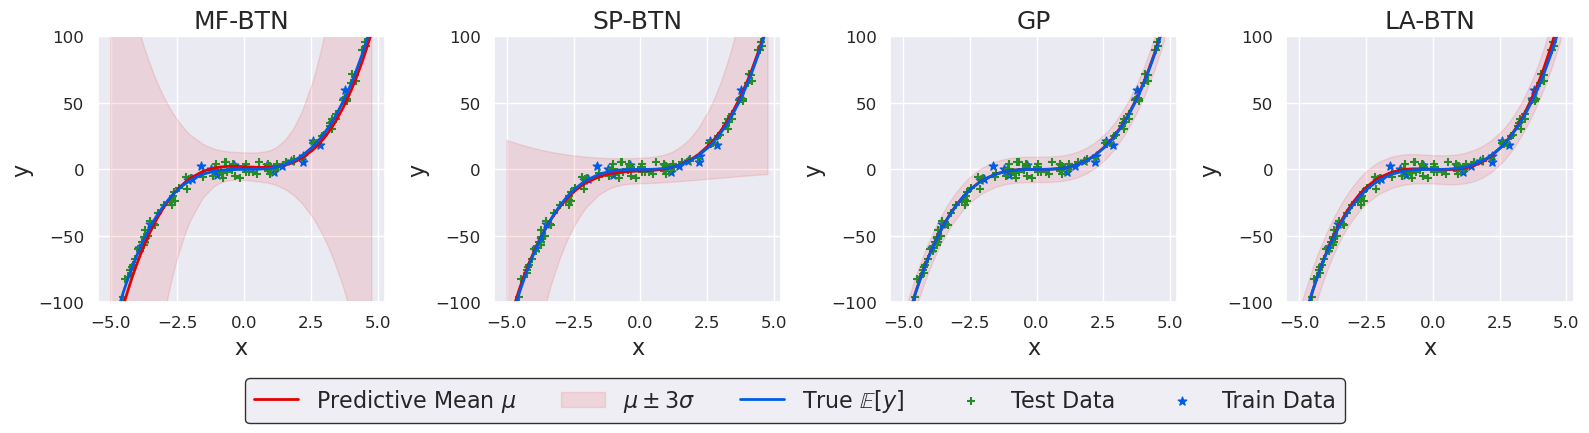

In [4]:
SAVE_DIR = Path(f'./artifacts/illustrative_example')
create_dir_if_not_exists(SAVE_DIR)

plot_x3_results_multiple(
    results=model2res, 
    data=(*data, y_test_true), 
    figsize=(16, 4), 
    y_limits=(-100, 100),
    save_path=SAVE_DIR / 'noisy_cubic_1d.png',
    dpi=1000,
)